In [8]:
# Credenciales (pon variables de entorno en producción)
CLIENT_ID     = "lbosp4quzjq9oe0nhgd7k291j7lf7y"
CLIENT_SECRET = "0qlq0q84p2zfzucsxa0ocgg167cnsb"

import pathlib, datetime as dt, time, json, requests, pandas as pd

RAW_DIR = pathlib.Path("datos/no_limpios");  RAW_DIR.mkdir(parents=True, exist_ok=True)
LIM_DIR = pathlib.Path("datos/limpios");     LIM_DIR.mkdir(parents=True, exist_ok=True)

def epoch(t: dt.datetime) -> int:
    return int(t.replace(tzinfo=dt.timezone.utc).timestamp())

def igdb_token() -> str:
    r = requests.post(
        "https://id.twitch.tv/oauth2/token",
        data={
            "client_id": CLIENT_ID,
            "client_secret": CLIENT_SECRET,
            "grant_type": "client_credentials",
        },
        timeout=10,
    )
    r.raise_for_status()
    return r.json()["access_token"]


In [9]:
def descargar_igdb_dia(date_str="2023-09-15"):
    # Ventana de 24 h en epoch
    day = dt.datetime.strptime(date_str, "%Y-%m-%d")
    ini, fin = epoch(day), epoch(day + dt.timedelta(days=1))

    headers = {
        "Client-ID": CLIENT_ID,
        "Authorization": f"Bearer {igdb_token()}",
    }

    query = f"""
    fields *;
    where first_release_date >= {ini} & first_release_date < {fin};
    limit 500;
    """

    url = "https://api.igdb.com/v4/games"
    data = requests.post(url, headers=headers, data=query, timeout=30).json()

    # JSON crudo en UTF-8
    out_json = RAW_DIR / f"igdb_{date_str}.json"
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"📥 {len(data)} juegos guardados → {out_json}")
    return data



In [10]:
#  ── EJECUTA ──
FECHA = "2023-09-15"        # cambia la fecha a la que quieras probar
raw_igdb = descargar_igdb_dia(FECHA)


📥 101 juegos guardados → datos\no_limpios\igdb_2023-09-15.json


In [13]:
# -------------------------------------------------------------
#  TRANSFORMACIÓN (limpieza & normalización mínima) – IGDB
# -------------------------------------------------------------
import json, pathlib, pandas as pd, datetime as dt

RAW_DIR   = pathlib.Path("datos/no_limpios")
CLEAN_DIR = pathlib.Path("datos/limpios")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

# --- localiza el JSON crudo (ajusta el nombre si cambias la fecha) ---
raw_file = next(RAW_DIR.glob("igdb_*.json"))
print(f"🗂️  Leyendo: {raw_file.name}")

with open(raw_file, encoding="utf-8") as f:
    games_raw = json.load(f)

def names_join(items, key="name"):
    """Convierte listas de dicts en 'val1;val2;…' evitando duplicados."""
    if not items:
        return None
    return ";".join(sorted({it[key] for it in items if it and key in it}))

rows = []
for g in games_raw:
    # ----------- selección de campos “útiles” -----------
    row = {
        # Identificación básica
        "igdb_id"      : g.get("id"),
        "name"         : g.get("name"),
        "release_date" : (
            dt.datetime.utcfromtimestamp(g["first_release_date"]).date()
            if g.get("first_release_date") else None
        ),

        # Descriptores de contenido
        "genres"            : names_join(g.get("genres")),
        "platforms"         : names_join(g.get("platforms")),
        "game_modes"        : names_join(g.get("game_modes")),
        "player_perspectives": names_join(g.get("player_perspectives")),

        # Métricas de “éxito” / recepción
        "rating"            : g.get("rating"),
        "rating_count"      : g.get("rating_count"),
        "aggregated_rating" : g.get("aggregated_rating"),
        "total_rating"      : g.get("total_rating"),
        "follows"           : g.get("follows"),
        "popularity"        : g.get("popularity"),
        "hypes"             : g.get("hypes"),

        # Compañías (para clasificar indie vs AAA o detectar colaboraciones)
        "developers" : names_join(
            [c["company"] for c in g.get("involved_companies", [])
             if c.get("developer")], key="name"
        ),
        "publishers" : names_join(
            [c["company"] for c in g.get("involved_companies", [])
             if c.get("publisher")], key="name"
        ),

        # Enlace con Steam
        "steam_appid" : next(
            (int(ext["uid"])
             for ext in g.get("external_games", [])
             if ext.get("category") == 1),
            None
        ),

        # Otros flags para filtrar en EDA/modelado
        "category"  : g.get("category"),
        "game_type" : g.get("game_type"),
        "status"    : g.get("status"),
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(f"✅ Juegos procesados: {len(df):,}")

# ----------- guardado ----------
out_csv = CLEAN_DIR / "igdb_clean.csv"
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"💾 CSV listo → {out_csv.relative_to(pathlib.Path.cwd())}")
df.head()


🗂️  Leyendo: igdb_2023-09-15.json


C:\Users\Unidad Academica MC\AppData\Local\Temp\ipykernel_28740\3170260588.py:31: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt.datetime.utcfromtimestamp(g["first_release_date"]).date()


TypeError: argument of type 'int' is not iterable

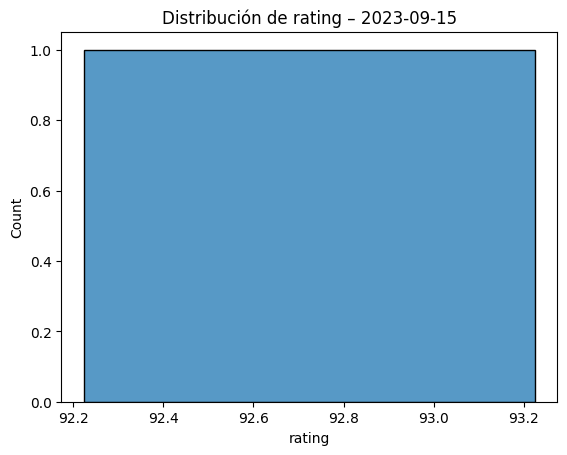

In [12]:
import seaborn as sns, matplotlib.pyplot as plt

# Histograma de rating (si existe)
if "rating" in df_igdb.columns and df_igdb["rating"].notna().any():
    sns.histplot(df_igdb["rating"].dropna())
    plt.title(f"Distribución de rating – {FECHA}")
    plt.show()

# Top plataformas (si existen)
if "platforms_name" in df_igdb.columns:
    (df_igdb.explode("platforms_name")["platforms_name"]
          .value_counts()
          .head(10)
          .plot.barh())
    plt.title(f"Plataformas más comunes – {FECHA}")
    plt.gca().invert_yaxis()
    plt.show()
